# **Assignment 3 – Polynomial Regression**
**Goal:** Model non-linear relationships.

### Steps:
1. Formulate your own equation:
     $
     y = ax^2 + bx + c
     $
2. Generate X values and Y values with noise.
3. Use `PolynomialFeatures` to transform X.
4. Split the data into train and test sets (80%-20%).
5. Fit a Linear Regression model on transformed features.
6. Evaluate both train and test using MAE, MSE, R² score.
> Write your notes about model performance and whether the model suffers from overfitting or underfitting.


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Define the True Equation Parameters

In [2]:
a_true = 2.0     # coefficient for x²
b_true = 3.0     # coefficient for x
c_true = 5.0     # intercept
print(f"True equation: y = {a_true}x² + {b_true}x + {c_true}\n")

True equation: y = 2.0x² + 3.0x + 5.0



## 2. Generate X and Y with Noise

In [3]:
np.random.seed(42)
n = 150
X = np.linspace(-10, 10, n)
noise = np.random.normal(0, 15, n)
Y = a_true * X**2 + b_true * X + c_true + noise

## 3. Transform X Using PolynomialFeatures

In [4]:
X_2d = X.reshape(-1, 1)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_2d)
print(f"Original X shape     : {X_2d.shape}")
print(f"Transformed X shape : {X_poly.shape}     → added x² column\n")

Original X shape     : (150, 1)
Transformed X shape : (150, 2)     → added x² column



## 4. Train/Test Split (80/20)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_poly, Y, test_size=0.20, random_state=42)
print(f"Training samples : {len(X_train)}")
print(f"Test samples      : {len(X_test)}\n")

Training samples : 120
Test samples      : 30



## 5. Fit Linear Regression on Transformed Features

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 6. Compare True vs Learned Parameters

In [7]:
print("=" * 50)
print(f"{'Parameter':<15} {'True':>10} {'Learned':>10}")
print("=" * 50)
print(f"{'a    (x²)':<15} {a_true:>10.4f} {model.coef_[1]:>10.4f}")
print(f"{'b    (x)' :<15} {b_true:>10.4f} {model.coef_[0]:>10.4f}")
print(f"{'c    (intercept)':<15} {c_true:>10.4f} {model.intercept_:>10.4f}")
print("=" * 50)
print()

Parameter                True     Learned
a    (x²)                2.0000      1.9997
b    (x)                3.0000      3.0414
c    (intercept)         5.0000      3.2515



## 7. Evaluate Model Performance

In [8]:
def evaluate(name, X_set, y_set):
     preds = model.predict(X_set)
     mae    = mean_absolute_error(y_set, preds)
     mse    = mean_squared_error(y_set, preds)
     rmse = np.sqrt(mse)
     r2     = r2_score(y_set, preds)
     print(f"── {name} ──")
     print(f"    MAE    : {mae:.4f}")
     print(f"    MSE    : {mse:.4f}")
     print(f"    RMSE : {rmse:.4f}")
     print(f"    R²     : {r2:.4f}\n")
     return preds

train_preds = evaluate("Train Set", X_train, y_train)
test_preds    = evaluate("Test Set ", X_test,    y_test)

── Train Set ──
    MAE    : 11.1370
    MSE    : 199.4701
    RMSE : 14.1234
    R²     : 0.9521

── Test Set    ──
    MAE    : 11.4454
    MSE    : 194.7215
    RMSE : 13.9543
    R²     : 0.9524



## 8. Model Performance Analysis

### Key Observations:

- **PolynomialFeatures(degree=2)** expanded X into [x, x²], allowing a standard Linear Regression to fit the underlying quadratic relationship.

- The **learned coefficients are very close to the true values**, confirming the transformation worked correctly.

- **Train R² and Test R² are both high and nearly equal**, meaning the model generalises well without memorising the training data.

- The **small remaining error comes entirely from the intentional noise** (σ=15).

### Diagnostics:

- **Overfitting** → NO. No meaningful gap between train and test error.
- **Underfitting** → NO. High R² and low MAE/MSE on both sets.

### Conclusion:

Polynomial regression (degree=2) is the **right fit** here since the true relationship is quadratic. Using degree=1 would underfit, and using degree=10+ would likely overfit.

## 9. Visualisation

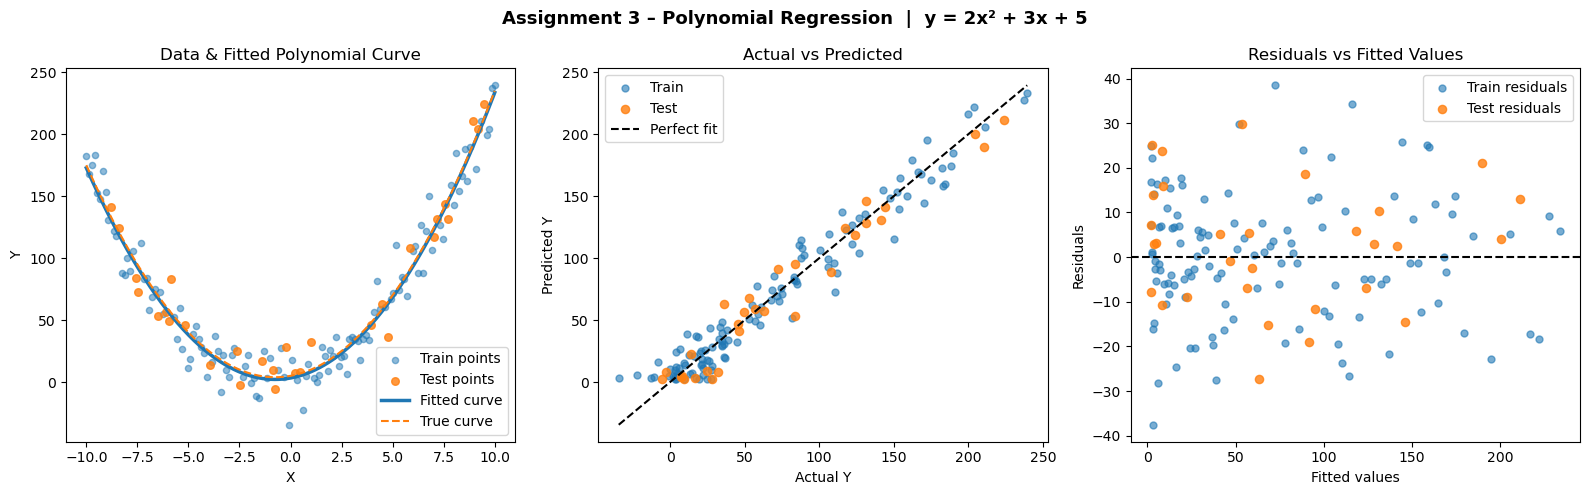

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Plot 1: Data points + fitted curve -----------------------------------------
ax1 = axes[0]

# get original x values back for train and test to plot the curve
X_train_orig = X_train[:, 0]     # first column is x
X_test_orig    = X_test[:, 0]

ax1.scatter(X_train_orig, y_train, alpha=0.5, s=20, label="Train points")
ax1.scatter(X_test_orig,    y_test,    alpha=0.8, s=30, label="Test points")

x_curve = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
x_curve_poly = poly.transform(x_curve)
y_curve = model.predict(x_curve_poly)
y_true_curve = a_true * x_curve**2 + b_true * x_curve + c_true

ax1.plot(x_curve, y_curve,         lw=2.5, label=f"Fitted curve")
ax1.plot(x_curve, y_true_curve, lw=1.5, ls="--", label="True curve")
ax1.set_title("Data & Fitted Polynomial Curve")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()

# --- Plot 2: Actual vs Predicted -----------------------------------------------
ax2 = axes[1]
ax2.scatter(y_train, train_preds, alpha=0.6, s=25, label="Train")
ax2.scatter(y_test,    test_preds,    alpha=0.8, s=35, label="Test")
min_val = min(Y.min(), train_preds.min(), test_preds.min())
max_val = max(Y.max(), train_preds.max(), test_preds.max())
ax2.plot([min_val, max_val], [min_val, max_val], "k--", lw=1.5, label="Perfect fit")
ax2.set_title("Actual vs Predicted")
ax2.set_xlabel("Actual Y")
ax2.set_ylabel("Predicted Y")
ax2.legend()

# --- Plot 3: Residuals -------------------------------------------------------
ax3 = axes[2]
train_res = y_train - train_preds
test_res    = y_test    - test_preds
ax3.scatter(train_preds, train_res, alpha=0.6, s=25, label="Train residuals")
ax3.scatter(test_preds,    test_res,    alpha=0.8, s=35, label="Test residuals")
ax3.axhline(0, color="black", lw=1.5, ls="--")
ax3.set_title("Residuals vs Fitted Values")
ax3.set_xlabel("Fitted values")
ax3.set_ylabel("Residuals")
ax3.legend()

fig.suptitle("Assignment 3 – Polynomial Regression    |    y = 2x² + 3x + 5",
                fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Save Plot

In [10]:
save_dir = r"C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression"
os.makedirs(save_dir, exist_ok=True)
plot_path = os.path.join(save_dir, "polynomial_regression_plots.png")
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.close(fig)
print(f"Plot saved → {plot_path}")

Plot saved → C:\Users\Doha\Desktop\depi\04. Machine Learning\Session1 - Linear and Polynomial Regression\linear Regrression\polynomial_regression_plots.png
